In [73]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [74]:
!wget https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv

--2025-10-26 17:08:15--  https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 80876 (79K) [text/plain]
Saving to: ‘course_lead_scoring.csv.2’

course_lead_scoring 100%[===================>]  78.98K  --.-KB/s    in 0.006s  

2025-10-26 17:08:15 (12.7 MB/s) - ‘course_lead_scoring.csv.2’ saved [80876/80876]



In [75]:
df = pd.read_csv("/kaggle/working/course_lead_scoring.csv")

In [76]:
df.head()

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score,converted
0,paid_ads,NaN,1,79450.0,unemployed,south_america,4,0.94,1
1,social_media,retail,1,46992.0,employed,south_america,1,0.80,0
2,events,healthcare,5,78796.0,unemployed,australia,3,0.69,1
3,paid_ads,retail,2,83843.0,NaN,australia,1,0.87,0
4,referral,education,3,85012.0,self_employed,europe,3,0.62,1


In [77]:
df.dtypes

lead_source                  object
industry                     object
number_of_courses_viewed      int64
annual_income               float64
employment_status            object
location                     object
interaction_count             int64
lead_score                  float64
converted                     int64
dtype: object

In [78]:
df_categorical = ["lead_source", "industry", "employment_status", "location"]

In [79]:
df[df_categorical].head()

,lead_source,industry,employment_status,location
0,paid_ads,NaN,unemployed,south_america
1,social_media,retail,employed,south_america
2,events,healthcare,unemployed,australia
3,paid_ads,retail,NaN,australia
4,referral,education,self_employed,europe


In [80]:
df_numerical = ["number_of_courses_viewed", "annual_income", "interaction_count", "lead_score"]

In [81]:
df[df_numerical].head()

,number_of_courses_viewed,annual_income,interaction_count,lead_score
0,1,79450.0,4,0.94
1,1,46992.0,1,0.80
2,5,78796.0,3,0.69
3,2,83843.0,1,0.87
4,3,85012.0,3,0.62


In [82]:
df[df_categorical].isnull().sum()

lead_source          128
industry             134
employment_status    100
location              63
dtype: int64

In [83]:
df[df_categorical] = df[df_categorical].fillna('NA')

In [84]:
df[df_numerical] = df[df_numerical].fillna(0)

In [85]:
X = df.drop("converted", axis=1)
y = df["converted"]

In [86]:
from sklearn.model_selection import train_test_split

df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

In [87]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [88]:
y_train = df_train.converted.values
y_val = df_val.converted.values
y_test = df_test.converted.values

del df_train['converted']
del df_val['converted']
del df_test['converted']

In [89]:
from sklearn.metrics import roc_curve

fpr, tpr, thresh = roc_curve(y, X["number_of_courses_viewed"])

In [90]:
fpr

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.00179533, 0.01615799, 0.0951526 , 0.35906643, 0.7540395 ,
       1.        ])

In [91]:
thresh

array([10,  9,  8,  7,  6,  5,  4,  3,  2,  1,  0])

In [92]:
for feature in df_numerical:
    print(feature, df["converted"].corr(df[feature]))

number_of_courses_viewed 0.4359136580211789
annual_income 0.05313144169625201
interaction_count 0.3745725177994036
lead_score 0.19367349758690283


In [93]:
from sklearn.metrics import roc_auc_score

for feature in df_numerical:
    print(feature, roc_auc_score(y, X[feature]))

number_of_courses_viewed 0.7608270430582144
annual_income 0.5426406260848865
interaction_count 0.7223206403681919
lead_score 0.6148050428003213


In [94]:
train_dict = df_train[df_categorical + df_numerical].to_dict(orient='records')

In [95]:
from sklearn.feature_extraction import DictVectorizer

dv = DictVectorizer(sparse=False)
dv.fit(train_dict)

DictVectorizer(sparse=False)

In [96]:
X_train = dv.transform(train_dict)

In [97]:
X_train

array([[9.5543e+04, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        2.0000e+00],
       [5.4924e+04, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 1.0000e+00,
        1.0000e+00],
       [7.7352e+04, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        2.0000e+00],
       ...,
       [7.3702e+04, 0.0000e+00, 0.0000e+00, ..., 1.0000e+00, 0.0000e+00,
        1.0000e+00],
       [9.3341e+04, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        1.0000e+00],
       [0.0000e+00, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        0.0000e+00]])

In [98]:
df_val

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score
0,organic_search,manufacturing,1,0.0,NA,asia,0,0.73
1,referral,education,2,58777.0,NA,north_america,0,0.94
2,paid_ads,technology,3,78148.0,employed,middle_east,2,0.80
3,social_media,technology,3,63854.0,employed,africa,1,0.10
4,referral,education,1,69099.0,unemployed,africa,4,0.98
...,...,...,...,...,...,...,...,...
288,paid_ads,finance,2,41947.0,self_employed,europe,4,0.10
289,paid_ads,other,2,0.0,self_employed,north_america,3,0.71
290,referral,NA,4,92215.0,employed,australia,4,0.57
291,events,other,2,53087.0,employed,europe,2,0.52


In [99]:
df_val.industry.unique()

array(['manufacturing', 'education', 'technology', 'other', 'healthcare',
       'finance', 'retail', 'NA'], dtype=object)

In [106]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(solver="liblinear", C=1.0, max_iter=1000)

model.fit(X_train, y_train)

val_dict = df_val[df_categorical + df_numerical].to_dict(orient='records')

# dv_val = DictVectorizer(sparse=False)
# dv.fit(val_dict)

X_val = dv.transform(val_dict)

y_pred = model.predict_proba(X_val)[:, 1]

# print(roc_auc_score(y_pred, y_val))

In [107]:
def calculate_prec_and_recall(y_pred, y_val,t):
    actual_positive = (y_val == 1)
    actual_negative = (y_val == 0)
    predict_positive = (y_pred >= t)
    predict_negative = (y_pred < t)
    tp = (predict_positive & actual_positive).sum()
    tn = (predict_negative & actual_negative).sum()
    
    fp = (predict_positive & actual_negative).sum()
    fn = (predict_negative & actual_positive).sum()
    p = tp / (tp + fp)
    r = tp / (tp + fn)

    return p,r

In [108]:
scores = []

thresholds = np.linspace(0, 1, 101)

for t in thresholds:
    actual_positive = (y_val == 1)
    actual_negative = (y_val == 0)
    
    predict_positive = (y_pred >= t)
    predict_negative = (y_pred < t)

    tp = (predict_positive & actual_positive).sum()
    tn = (predict_negative & actual_negative).sum()

    fp = (predict_positive & actual_negative).sum()
    fn = (predict_negative & actual_positive).sum()

    p = tp / (tp + fp)
    r = tp / (tp + fn)
    
    scores.append((t, tp, fp, fn, tn, p, r))

/tmp/ipykernel_37/1180181809.py:18: RuntimeWarning: invalid value encountered in scalar divide
  p = tp / (tp + fp)


In [109]:
columns = ['threshold', 'tp', 'fp', 'fn', 'tn', 'p', 'r']
df_scores = pd.DataFrame(scores, columns=columns)

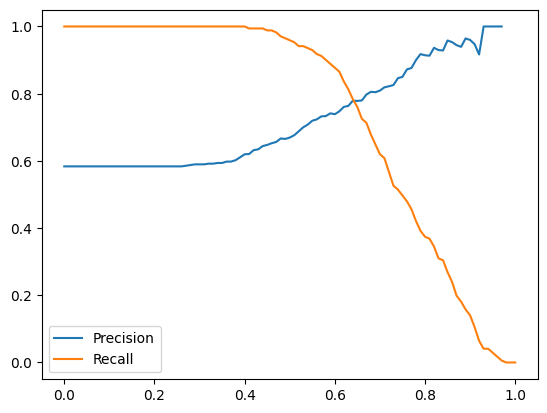

In [110]:
plt.plot(df_scores.threshold, df_scores['p'], label='Precision')
plt.plot(df_scores.threshold, df_scores['r'], label='Recall')
plt.legend()

In [113]:
scores = []

thresholds = np.linspace(0, 1, 101)

for t in thresholds:
    actual_positive = (y_val == 1)
    actual_negative = (y_val == 0)
    
    predict_positive = (y_pred >= t)
    predict_negative = (y_pred < t)

    tp = (predict_positive & actual_positive).sum()
    tn = (predict_negative & actual_negative).sum()

    fp = (predict_positive & actual_negative).sum()
    fn = (predict_negative & actual_positive).sum()

    p = tp / (tp + fp)
    r = tp / (tp + fn)

    f_1 = 2*(p*r)/(p+r)
    
    scores.append((t, tp, fp, fn, tn, p, r, f_1))

/tmp/ipykernel_37/2027743115.py:18: RuntimeWarning: invalid value encountered in scalar divide
  p = tp / (tp + fp)


In [114]:
columns = ['threshold', 'tp', 'fp', 'fn', 'tn', 'p', 'r', 'f_1']
df_scores = pd.DataFrame(scores, columns=columns)

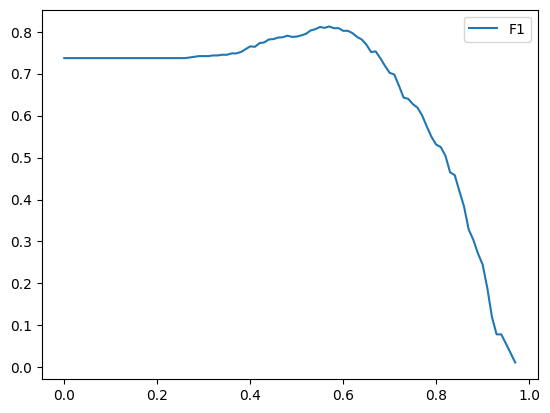

In [115]:
plt.plot(df_scores.threshold, df_scores['f_1'], label='F1')
plt.legend()

In [120]:
from sklearn.model_selection import KFold

X_dict = X[df_categorical + df_numerical].to_dict(orient='records')

X_full = dv.transform(X_dict)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

y_pred_check = 0

for train_index, test_index in kf.split(X):
    X_train, X_test = X_full[train_index], X_full[test_index]
    y_train, y_test = y[train_index], y[test_index]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    scores.append(roc_auc_score(y_test, y_pred))

print(f"AUC scores for each fold: {scores}")
print()
# print(f"Average accuracy: {np.std(scores)}")


[0 1 0 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1
 1 0 1 1 1 1 1 1 1 1 0 0 1 0 1 1 0 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1
 1 1 0 1 1 1 1 1 1 0 0 1 0 1 1 1 0 0 0 1 1 1 0 1 1 1 1 0 1 0 1 1 1 1 1 0 1
 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 0 1
 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 0 1 1 0 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 0 1 1 1
 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 1 1 1 1 0 1 1 1 0 1
 0 1 1 1 0 0 0 1 1 1 1 1 1 1 1 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1]
[0 1 1 1 0 1 1 1 0 1 1 1 0 1 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1
 0 1 0 1 1 1 1 0 1 1 0 1 1 1 1 0 0 1 1 1 0 0 1 1 1 0 1 0 1 1 1 1 1 1 1 1 1
 1 1 1 1 0 1 0 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1
 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 0 1 1 1 0 1 1 1 1 0 1 1 1 1 0 0 1 1 1 1 1 1
 0 1 1 1 1 0 1 0 1 1 1 1 0 1 1 1 1 1 1 0 1 0 1 0 1 1 0 1 1 1 1 0 1 1 1 1 1
 0 1 1 1 1 1 0 1 0 1 1 0 1 1 1

In [119]:
scores[0]

(0.0, 171, 122, 0, 0, 0.5836177474402731, 1.0, 0.7370689655172414)

In [123]:
from sklearn.model_selection import cross_val_score

# Calculate ROC AUC scores using cross_val_score
# 'roc_auc' is the scoring metric for binary classification
scores = cross_val_score(model, X_full, y, cv=5, scoring='roc_auc')

print(f"ROC AUC scores for each fold: {scores}")
print(f"Standard deviation: {np.std(scores)}")


ROC AUC scores for each fold: [0.78694751 0.87036306 0.80926783 0.85804589 0.78866159]
Standard deviation: 0.035038171077861065


In [126]:
for C in [0.000001, 0.001, 1]:
    model = LogisticRegression(solver='liblinear', C=C, max_iter=1000)
    scores = cross_val_score(model, X_full, y, cv=5, scoring='roc_auc')

    print(f"For C = {C}")
    print(f"ROC AUC scores for each fold: {scores}")
    print(f"ROC AUC Mean: {scores.mean()}")
    print(f"Standard deviation: {np.std(scores)}")

For C = 1e-06
ROC AUC scores for each fold: [0.61557814 0.52298737 0.55268528 0.53292519 0.53217859]
ROC AUC Mean: 0.5512709137709138
Standard deviation: 0.03358112767895442
For C = 0.001
ROC AUC scores for each fold: [0.8663674  0.88960142 0.84037629 0.87755712 0.84007765]
ROC AUC Mean: 0.8627959747434886
Standard deviation: 0.01983906795483652
For C = 1
ROC AUC scores for each fold: [0.78694751 0.87036306 0.80926783 0.85804589 0.78866159]
ROC AUC Mean: 0.8226571776986141
Standard deviation: 0.035038171077861065
